In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('dados_vendas.xlsx')


In [3]:
df = pd.read_excel('dados_vendas.xlsx')

df.columns = df.columns.str.lower().str.strip()

df['data'] = pd.to_datetime(df['data'], errors='coerce')

df = df.dropna(subset=['data', 'quantidade vendida'])

df = df.sort_values('data')

df.head()

,data,quantidade vendida
0,2022-01-01,102
1,2022-01-02,102
2,2022-01-03,107
3,2022-01-04,102
4,2022-01-05,104


## Tratamento dos Dados de Vendas

Primeiro, os dados foram carregados a partir de um arquivo Excel.

Em seguida, os nomes das colunas foram padronizados, deixando tudo em letras minúsculas e sem espaços desnecessários.

Depois, a coluna de data foi convertida para o formato correto, garantindo que seja reconhecida como data.

Também foram removidos os registros com valores ausentes nas colunas de data e quantidade vendida, evitando erros na análise.

Por fim, os dados foram organizados em ordem crescente de data.

O comando final (`head()`) mostra as primeiras linhas do conjunto de dados já tratado.


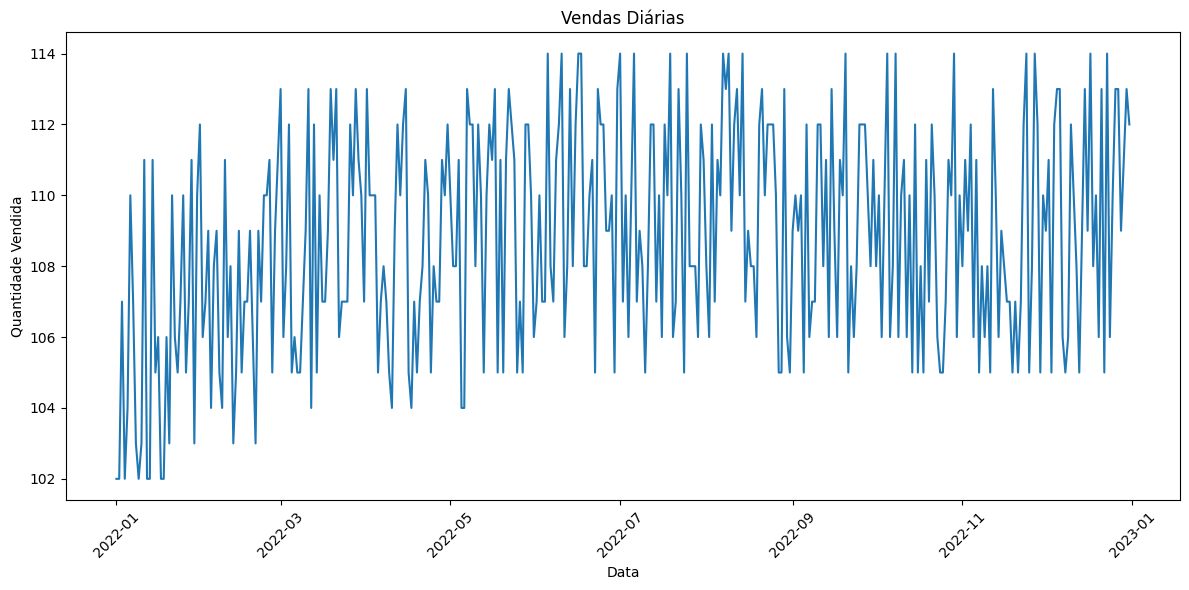

In [4]:
# Gráfico de vendas diárias

plt.figure(figsize=(12, 6))  
plt.plot(df['data'], df['quantidade vendida'])
plt.title('Vendas Diárias')
plt.xlabel('Data')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análise do Gráfico de Vendas Diárias

O gráfico mostra a quantidade de vendas ao longo dos dias.

No eixo horizontal estão as datas, e no eixo vertical está a quantidade vendida. A linha representa como as vendas mudam de um dia para o outro.

Com ele, dá para ver se as vendas estão aumentando, diminuindo ou se mantêm estáveis. Também é possível identificar dias com mais vendas (picos) e dias com menos vendas (quedas).

Esse tipo de gráfico ajuda a entender o comportamento das vendas ao longo do tempo.


In [5]:
maior = df.loc[df['quantidade vendida'].idxmax()]
print(f"Maior venda: {maior['data']} → {maior['quantidade vendida']}")

Maior venda: 2022-06-05 00:00:00 → 114


In [6]:
menor = df.loc[df['quantidade vendida'].idxmin()]
print(f"Menor venda: {menor['data']} → {menor['quantidade vendida']}")

Menor venda: 2022-01-01 00:00:00 → 102


In [7]:
media = df['quantidade vendida'].mean()
print(f"Média de vendas: {media:.2f}")

Média de vendas: 108.73


In [8]:
df['mes'] = df['data'].dt.month

media_mensal = df.groupby('mes')['quantidade vendida'].mean()

media_mensal

mes
1     105.741935
2     107.250000
3     108.709677
4     108.400000
5     109.290323
6     109.900000
7     109.322581
8     109.870968
9     109.300000
10    108.645161
11    108.433333
12    109.774194
Name: quantidade vendida, dtype: float64

## Cálculo da Média de Vendas por Mês

Primeiro, foi criada uma coluna chamada "mes" a partir da coluna de datas, pegando apenas o número do mês de cada registro.

Depois, os dados foram agrupados por mês, e foi calculada a média da quantidade vendida em cada um deles.

O resultado mostra a média de vendas para cada mês, permitindo entender como as vendas se comportam ao longo do ano.


<Figure size 640x480 with 0 Axes>

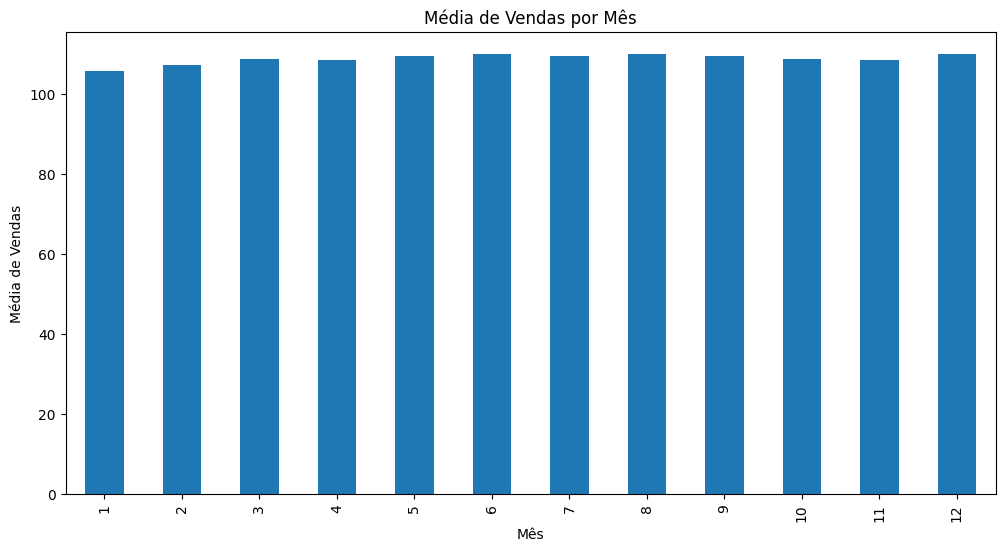

In [9]:
plt.figure()
plt.figure(figsize=(12, 6)) 
media_mensal.plot(kind='bar')
plt.title('Média de Vendas por Mês')
plt.xlabel('Mês')
plt.ylabel('Média de Vendas')
plt.show()

## Análise do Gráfico de Média de Vendas por Mês

O gráfico mostra a média de vendas em cada mês.

No eixo horizontal estão os meses, e no eixo vertical está a média de vendas. As barras representam o valor médio vendido em cada mês.

Com ele, dá para comparar quais meses tiveram melhor desempenho e quais tiveram menor média de vendas.

Esse tipo de gráfico ajuda a identificar quais períodos do ano são mais fortes ou mais fracos em vendas.
